# Distillation Results — v4 Teacher Comparison

Compares student (Llama-3.1-8B) F1 across all three v4 teacher models, split by intent condition.

In [10]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

plt.rcParams["figure.dpi"] = 120

In [11]:
DATA_DIR      = Path("../../data/safety_experiment/pipeline")
BASELINES_DIR = Path("../../data/safety_experiment")
FIGS_DIR      = Path("../../data/imgs")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# v4 teacher slugs → display names
TEACHERS = {
    "openai-gpt-oss-120b-v4":                          "GPT-OSS-120B",
    "moonshotai-kimi-k2.5-v4":                         "Kimi K2.5",
    "RedHatAI-gemma-3-27b-it-quantized.w4a16-v4":      "Gemma 3 27B",
}

DATASETS = {
    "annotated-intents": "Annotated Intents",
    "wildguardmix":      "WildguardTest",
    "xstest":            "XSTest",
}

CONDITIONS = {
    "finetuned_reasoning_classification": "Without Intent",
    "finetuned_reasoning_generation":     "With Intent",
}

DATASET_ORDER   = ["Annotated Intents", "WildguardTest", "XSTest", "Average"]
CONDITION_ORDER = ["Without Intent", "With Intent"]

TEACHER_COLORS = {
    "GPT-OSS-120B":  "#4393c3",
    "Kimi K2.5":     "#d6604d",
    "Gemma 3 27B":   "#74c476",
}
WILDGUARD_COLOR = "#b3b3b3"

STUDENT_FILE = "meta-llama_Llama-3.1-8B-Instruct"


In [12]:
def compute_metrics(path: Path) -> dict:
    records = [json.loads(l) for l in path.read_text().splitlines() if l.strip()]
    before  = len(records)
    records = [r for r in records if r.get("predicted_harm") is not None]
    if (dropped := before - len(records)):
        print(f"  [{path.parent.parent.name}/{path.parent.name}] dropped {dropped}/{before} unparsed")
    y_true = [r["true_harm_binary"] for r in records]
    y_pred = [r["predicted_harm"]   for r in records]
    return {
        "f1":        f1_score(y_true, y_pred, pos_label="harmful"),
        "precision": precision_score(y_true, y_pred, pos_label="harmful", zero_division=0),
        "recall":    recall_score(y_true, y_pred, pos_label="harmful", zero_division=0),
    }


# ── Distillation results ──────────────────────────────────────────────────────
rows = []
for slug, teacher_name in TEACHERS.items():
    for ds_key, ds_name in DATASETS.items():
        for cond_key, cond_name in CONDITIONS.items():
            fpath = DATA_DIR / slug / ds_key / f"{STUDENT_FILE}_{cond_key}.jsonl"
            if not fpath.exists():
                print(f"MISSING: {fpath}")
                continue
            rows.append({"teacher": teacher_name, "condition": cond_name,
                         "dataset": ds_name, **compute_metrics(fpath)})

df = pd.DataFrame(rows)

avg = (df.groupby(["teacher", "condition"])[["f1", "precision", "recall"]]
         .mean().reset_index().assign(dataset="Average"))
df = pd.concat([df, avg], ignore_index=True)

# ── WildGuard baseline ────────────────────────────────────────────────────────
wg_f1 = {}
for ds_key, ds_name in DATASETS.items():
    fpath = BASELINES_DIR / ds_key / "allenai_wildguard_wildguard_classification.jsonl"
    if not fpath.exists():
        print(f"MISSING (WildGuard): {fpath}")
        continue
    wg_f1[ds_name] = compute_metrics(fpath)["f1"]
wg_f1["Average"] = np.mean(list(wg_f1.values()))

print(f"Loaded {len(df)} distillation rows ({len(TEACHERS)} teachers × {len(DATASETS)} datasets × {len(CONDITIONS)} conditions + averages)")
print(f"WildGuard F1: { {k: f'{v:.3f}' for k, v in wg_f1.items()} }")
df


  [moonshotai-kimi-k2.5-v4/annotated-intents] dropped 1/173 unparsed
  [moonshotai-kimi-k2.5-v4/wildguardmix] dropped 3/1699 unparsed
  [RedHatAI-gemma-3-27b-it-quantized.w4a16-v4/annotated-intents] dropped 1/173 unparsed
  [RedHatAI-gemma-3-27b-it-quantized.w4a16-v4/wildguardmix] dropped 8/1699 unparsed
Loaded 24 distillation rows (3 teachers × 3 datasets × 2 conditions + averages)
WildGuard F1: {'Annotated Intents': '0.707', 'WildguardTest': '0.887', 'XSTest': '0.945', 'Average': '0.846'}


,teacher,condition,dataset,f1,precision,recall
0,GPT-OSS-120B,Without Intent,Annotated Intents,0.722892,0.731707,0.714286
1,GPT-OSS-120B,With Intent,Annotated Intents,0.524590,0.842105,0.380952
2,GPT-OSS-120B,Without Intent,WildguardTest,0.877919,0.883221,0.872679
3,GPT-OSS-120B,With Intent,WildguardTest,0.837004,0.937500,0.755968
4,GPT-OSS-120B,Without Intent,XSTest,0.923810,0.881818,0.970000
5,GPT-OSS-120B,With Intent,XSTest,0.928395,0.917073,0.940000
6,Kimi K2.5,Without Intent,Annotated Intents,0.618705,0.767857,0.518072
7,Kimi K2.5,With Intent,Annotated Intents,0.666667,0.739130,0.607143
8,Kimi K2.5,Without Intent,WildguardTest,0.817046,0.912972,0.739362
9,Kimi K2.5,With Intent,WildguardTest,0.823450,0.836986,0.810345


## F1 Score — With vs Without Intent, All Teachers & Datasets

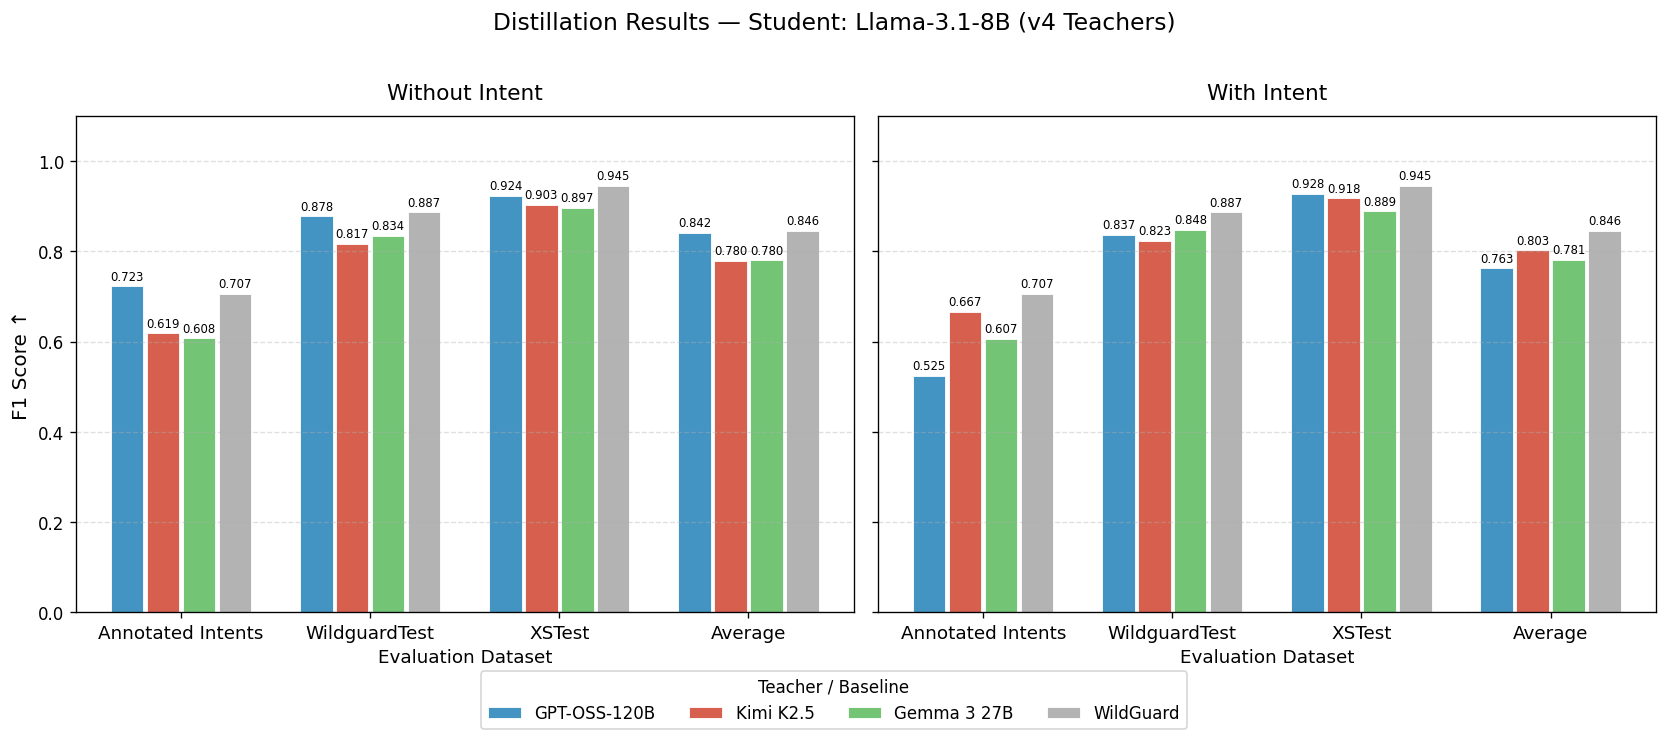

In [13]:
teacher_names = list(TEACHERS.values())
all_bars      = teacher_names + ["WildGuard"]
n_bars        = len(all_bars)
bar_w         = 0.19
x             = np.arange(len(DATASET_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, condition in zip(axes, CONDITION_ORDER):
    df_c    = df[df["condition"] == condition]
    offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_w

    for offset, name in zip(offsets, all_bars):
        if name == "WildGuard":
            f1_vals = [wg_f1.get(ds, 0.0) for ds in DATASET_ORDER]
            color   = WILDGUARD_COLOR
        else:
            df_ct   = df_c[df_c["teacher"] == name].set_index("dataset")
            f1_vals = [df_ct.loc[ds, "f1"] if ds in df_ct.index else 0.0 for ds in DATASET_ORDER]
            color   = TEACHER_COLORS.get(name, "#aaaaaa")

        bars = ax.bar(
            x + offset, f1_vals, bar_w * 0.9,
            label=name,
            color=color,
            edgecolor="white", linewidth=0.5,
        )
        for bar, v in zip(bars, f1_vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.007,
                f"{v:.3f}",
                ha="center", va="bottom", fontsize=7,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(DATASET_ORDER, fontsize=11)
    ax.set_title(condition, fontsize=13, pad=10)
    ax.set_xlabel("Evaluation Dataset", fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("F1 Score ↑", fontsize=12)
fig.suptitle("Distillation Results — Student: Llama-3.1-8B (v4 Teachers)", fontsize=14, y=1.02)

# Shared legend below both subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=len(handles),
    bbox_to_anchor=(0.5, -0.08),
    fontsize=10,
    frameon=True,
    title="Teacher / Baseline",
    title_fontsize=10,
)

plt.tight_layout()
fig.savefig(FIGS_DIR / "distillation_v4_f1.pdf", bbox_inches="tight")
plt.show()


## Detailed Metrics Table

In [14]:
fmt = df.copy()
for col in ["f1", "precision", "recall"]:
    fmt[col] = fmt[col].apply(lambda v: f"{v:.4f}")

teacher_order = list(TEACHERS.values())
(fmt[["teacher", "condition", "dataset", "f1", "precision", "recall"]]
   .assign(
       teacher_rank  = fmt["teacher"].map({t: i for i, t in enumerate(teacher_order)}),
       cond_rank     = fmt["condition"].map({c: i for i, c in enumerate(CONDITION_ORDER)}),
       dataset_rank  = fmt["dataset"].map({d: i for i, d in enumerate(DATASET_ORDER)}),
   )
   .sort_values(["teacher_rank", "cond_rank", "dataset_rank"])
   .drop(columns=["teacher_rank", "cond_rank", "dataset_rank"])
   .reset_index(drop=True))

,teacher,condition,dataset,f1,precision,recall
0,GPT-OSS-120B,Without Intent,Annotated Intents,0.7229,0.7317,0.7143
1,GPT-OSS-120B,Without Intent,WildguardTest,0.8779,0.8832,0.8727
2,GPT-OSS-120B,Without Intent,XSTest,0.9238,0.8818,0.9700
3,GPT-OSS-120B,Without Intent,Average,0.8415,0.8322,0.8523
4,GPT-OSS-120B,With Intent,Annotated Intents,0.5246,0.8421,0.3810
5,GPT-OSS-120B,With Intent,WildguardTest,0.8370,0.9375,0.7560
6,GPT-OSS-120B,With Intent,XSTest,0.9284,0.9171,0.9400
7,GPT-OSS-120B,With Intent,Average,0.7633,0.8989,0.6923
8,Kimi K2.5,Without Intent,Annotated Intents,0.6187,0.7679,0.5181
9,Kimi K2.5,Without Intent,WildguardTest,0.8170,0.9130,0.7394
